# Exploratory Data Analysis

Detailed analysis of the preprocessed Amazon review dataset across six product categories:
Apparel, Beauty, Books, Furniture, Mobile, Outdoors.

**Sections covered here:**
1. Dataset Overview — shape, dtypes, nulls, descriptive statistics
2. Sentiment Distribution — per category and overall

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

PROCESSED_DIR = "../data/processed"
CATEGORIES = ["Apparel", "Beauty", "Books", "Furniture", "Mobile", "Outdoors"]
PALETTE = sns.color_palette("muted", len(CATEGORIES))
CAT_COLOR = dict(zip(CATEGORIES, PALETTE))

dfs = {
    cat: pd.read_parquet(os.path.join(PROCESSED_DIR, f"{cat.lower()}_processed.parquet"))
    for cat in CATEGORIES
}
combined = pd.concat(dfs.values(), ignore_index=True)
print(f"Total rows loaded: {len(combined):,}")

Total rows loaded: 22,170,956


---
## 1. Dataset Overview

### 1a. Row & Column Counts per Category

In [5]:
shape_summary = pd.DataFrame(
    {cat: {"rows": len(df), "columns": df.shape[1]} for cat, df in dfs.items()}
).T
shape_summary["rows"] = shape_summary["rows"].astype(int)
shape_summary["columns"] = shape_summary["columns"].astype(int)
shape_summary.loc["TOTAL"] = [shape_summary["rows"].sum(), shape_summary["columns"].iloc[0]]
shape_summary

,rows,columns
Apparel,5876656,18
Beauty,5090248,18
Books,3101044,18
Furniture,790842,18
Mobile,5013710,18
Outdoors,2298456,18
TOTAL,22170956,18


### 1b. Column Types & Null Counts

In [8]:
sample = dfs["Apparel"]
dtype_df = pd.DataFrame({"dtype": sample.dtypes})
null_counts = pd.DataFrame(
    {cat: df.isnull().sum() for cat, df in dfs.items()}
)
null_counts["total_nulls"] = null_counts.sum(axis=1)
overview = dtype_df.join(null_counts)
overview

,dtype,Apparel,Beauty,Books,Furniture,Mobile,Outdoors,total_nulls
customer_id,int64,0,0,0,0,0,0,0
review_id,str,0,0,0,0,0,0,0
product_id,str,0,0,0,0,0,0,0
product_parent,int64,0,0,0,0,0,0,0
product_title,str,0,0,0,0,0,0,0
product_category,str,0,0,0,0,0,0,0
helpful_votes,int64,0,0,0,0,0,0,0
total_votes,int64,0,0,0,0,0,0,0
vine,str,0,0,0,0,0,0,0
verified_purchase,str,0,0,0,0,0,0,0


### 1c. Descriptive Statistics — Numeric Columns

In [9]:
num_cols = ["helpful_votes", "total_votes", "helpfulness_ratio", "review_year", "review_month"]
combined[num_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.99]).round(4)

,helpful_votes,total_votes,helpfulness_ratio,review_year,review_month
count,2.217096e+07,2.217096e+07,2.217096e+07,2.217096e+07,2.217096e+07
mean,2.829600e+00,3.655000e+00,3.167000e-01,2.012082e+03,6.236400e+00
std,2.367720e+01,2.665760e+01,4.288000e-01,4.393000e+00,3.434700e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,1.995000e+03,1.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,2.012000e+03,3.000000e+00
50%,0.000000e+00,0.000000e+00,0.000000e+00,2.014000e+03,6.000000e+00
75%,1.000000e+00,2.000000e+00,8.000000e-01,2.015000e+03,9.000000e+00
90%,6.000000e+00,7.000000e+00,1.000000e+00,2.015000e+03,1.100000e+01
99%,4.100000e+01,5.200000e+01,1.000000e+00,2.015000e+03,1.200000e+01
max,4.127800e+04,4.188900e+04,1.000000e+00,2.015000e+03,1.200000e+01


In [10]:
stats_rows = []
for cat, df in dfs.items():
    for col in ["helpful_votes", "total_votes", "helpfulness_ratio"]:
        s = df[col].astype(float)
        stats_rows.append({
            "category":  cat,
            "column":    col,
            "mean":      round(s.mean(), 4),
            "median":    round(s.median(), 4),
            "std":       round(s.std(), 4),
            "min":       round(s.min(), 4),
            "max":       round(s.max(), 4),
            "p90":       round(s.quantile(0.90), 4),
            "p99":       round(s.quantile(0.99), 4),
        })

pd.DataFrame(stats_rows).set_index(["category", "column"])

mean  median      std  min      max   p90  \
category  column                                                            
Apparel   helpful_votes       0.9725     0.0  20.7223  0.0  41278.0   2.0   
          total_votes         1.1640     0.0  21.2613  0.0  41889.0   2.0   
          helpfulness_ratio   0.2223     0.0   0.4004  0.0      1.0   1.0   
Beauty    helpful_votes       1.7103     0.0  17.2433  0.0  13362.0   3.0   
          total_votes         2.1654     0.0  18.4289  0.0  13636.0   4.0   
          helpfulness_ratio   0.3056     0.0   0.4296  0.0      1.0   1.0   
Books     helpful_votes       9.3324     4.0  26.2236  0.0  15835.0  21.0   
          total_votes        12.3971     5.0  30.2423  0.0  16352.0  28.0   
          helpfulness_ratio   0.6723     0.8   0.3589  0.0      1.0   1.0   
Furniture helpful_votes       2.3989     0.0  19.0188  0.0   6390.0   5.0   
          total_votes         2.7815     0.0  20.3155  0.0   6509.0   5.0   
          helpfulness_ratio   0.3639     0.0   0.4549  0.0      1.0   1.0   
Mobile    helpful_votes       2.6390     0.0  32.9354  0.0  10466.0   3.0   
          total_votes         3.4412     0.0  38.6532  0.0  12016.0   5.0   
          helpfulness_ratio   0.2183     0.0   0.3759  0.0      1.0   1.0   
Outdoors  helpful_votes       1.8471     0.0  12.7692  0.0   2703.0   3.0   
          total_votes         2.2949     0.0  13.6259  0.0   2751.0   5.0   
          helpfulness_ratio   0.3013     0.0   0.4311  0.0      1.0   1.0   

                               p99  
category  column                    
Apparel   helpful_votes       14.0  
          total_votes         16.0  
          helpfulness_ratio    1.0  
Beauty    helpful_votes       23.0  
          total_votes         27.0  
          helpfulness_ratio    1.0  
Books     helpful_votes       84.0  
          total_votes        106.0  
          helpfulness_ratio    1.0  
Furniture helpful_votes       33.0  
          total_votes         37.0  
          helpfulness_ratio    1.0  
Mobile    helpful_votes       41.0  
          total_votes         52.0  
          helpfulness_ratio    1.0  
Outdoors  helpful_votes       27.0  
          total_votes         32.0  
          helpfulness_ratio    1.0

### 1d. Review Text Length Statistics

In [11]:
len_stats = []
for cat, df in dfs.items():
    # sample 100k rows to avoid memory crash on 22M rows
    sample = df["review"].sample(min(100_000, len(df)), random_state=42)
    word_counts = sample.str.split().str.len()
    len_stats.append({
        "category":     cat,
        "mean_words":   round(word_counts.mean(), 1),
        "median_words": round(word_counts.median(), 1),
        "std_words":    round(word_counts.std(), 1),
        "p90_words":    round(word_counts.quantile(0.90), 1),
        "p99_words":    round(word_counts.quantile(0.99), 1),
        "max_words":    int(word_counts.max()),
    })

pd.DataFrame(len_stats).set_index("category")

,mean_words,median_words,std_words,p90_words,p99_words,max_words
category,,,,,,
Apparel,38.0,27.0,43.6,80.0,203.0,2036
Beauty,52.1,33.0,70.4,112.0,305.0,5668
Books,157.9,110.0,160.1,312.0,854.0,4490
Furniture,60.5,38.0,79.6,129.0,353.0,3495
Mobile,32.6,26.0,46.8,57.0,158.0,9027
Outdoors,60.4,37.0,86.6,131.0,369.0,4027


---
## 2. Sentiment Distribution

### 2a. Sentiment Counts & Percentages per Category

In [12]:
SENTIMENT_ORDER = ["positive", "neutral", "negative"]
SENTIMENT_PALETTE = {"positive": "#4caf50", "neutral": "#ff9800", "negative": "#f44336"}

sent_counts = pd.DataFrame(
    {cat: df["sentiment_label"].value_counts() for cat, df in dfs.items()}
).T.fillna(0).astype(int)[SENTIMENT_ORDER]

sent_pct = sent_counts.div(sent_counts.sum(axis=1), axis=0).mul(100).round(2)
sent_pct.columns = [f"{c} %" for c in sent_pct.columns]

pd.concat([sent_counts, sent_pct], axis=1)

,positive,neutral,negative,positive %,neutral %,negative %
Apparel,4445410,620416,810830,75.65,10.56,13.80
Beauty,3976696,396383,717169,78.12,7.79,14.09
Books,2447521,249587,403936,78.93,8.05,13.03
Furniture,600458,73426,116958,75.93,9.28,14.79
Mobile,3695141,464840,853729,73.70,9.27,17.03
Outdoors,1849352,178785,270319,80.46,7.78,11.76


### 2b. Stacked Bar Chart — Sentiment Count per Category

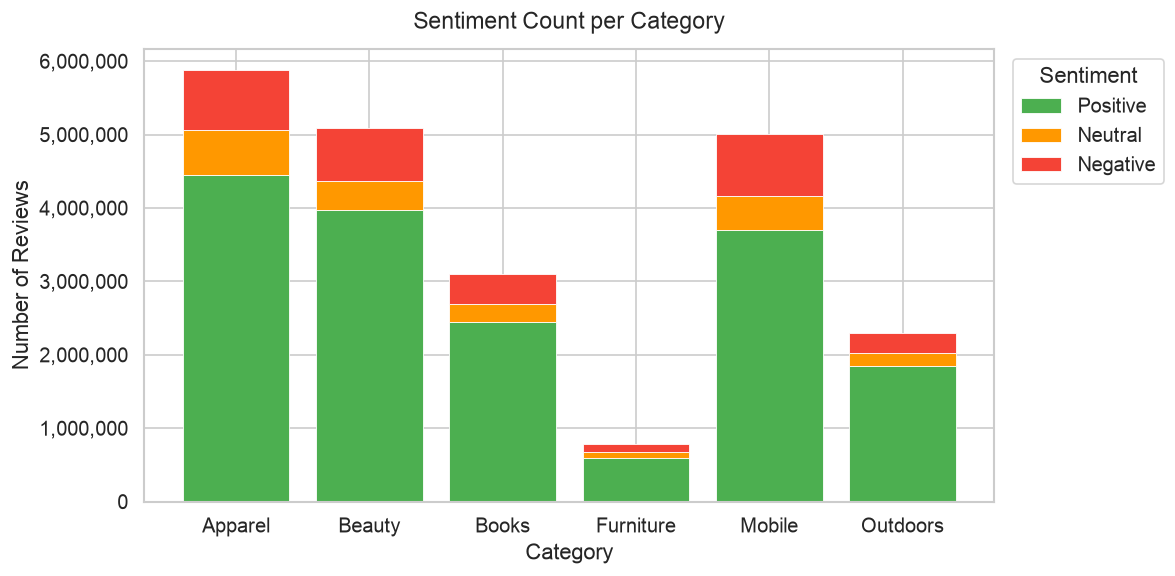

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(CATEGORIES))
x = np.arange(len(CATEGORIES))

for sentiment in SENTIMENT_ORDER:
    values = sent_counts[sentiment].values
    ax.bar(x, values, bottom=bottom, label=sentiment.capitalize(),
           color=SENTIMENT_PALETTE[sentiment], edgecolor="white", linewidth=0.5)
    bottom += values

ax.set_xticks(x)
ax.set_xticklabels(CATEGORIES)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.set_title("Sentiment Count per Category", fontsize=14, pad=12)
ax.set_xlabel("Category")
ax.set_ylabel("Number of Reviews")
ax.legend(title="Sentiment", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 2c. Normalized Stacked Bar — Sentiment % per Category

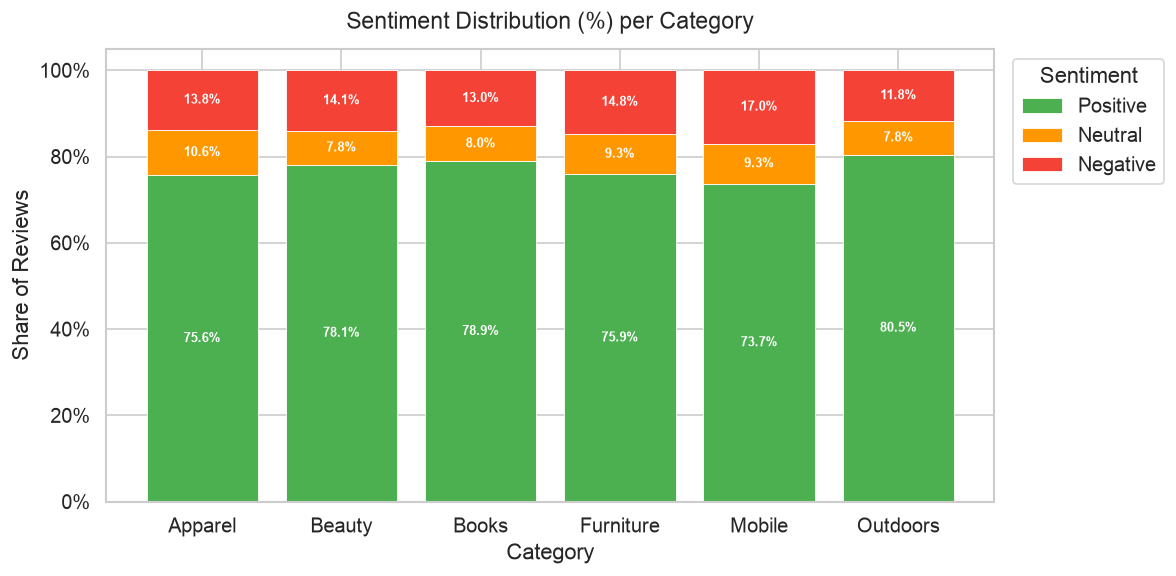

In [14]:
sent_norm = sent_counts.div(sent_counts.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(CATEGORIES))

for sentiment in SENTIMENT_ORDER:
    values = sent_norm[sentiment].values
    bars = ax.bar(x, values, bottom=bottom, label=sentiment.capitalize(),
                  color=SENTIMENT_PALETTE[sentiment], edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, values):
        if val > 0.04:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + val / 2,
                f"{val*100:.1f}%",
                ha="center", va="center", fontsize=8, color="white", fontweight="bold"
            )
    bottom += values

ax.set_xticks(x)
ax.set_xticklabels(CATEGORIES)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title("Sentiment Distribution (%) per Category", fontsize=14, pad=12)
ax.set_xlabel("Category")
ax.set_ylabel("Share of Reviews")
ax.legend(title="Sentiment", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 2d. Pie Chart — Overall Sentiment Share (All Categories Combined)

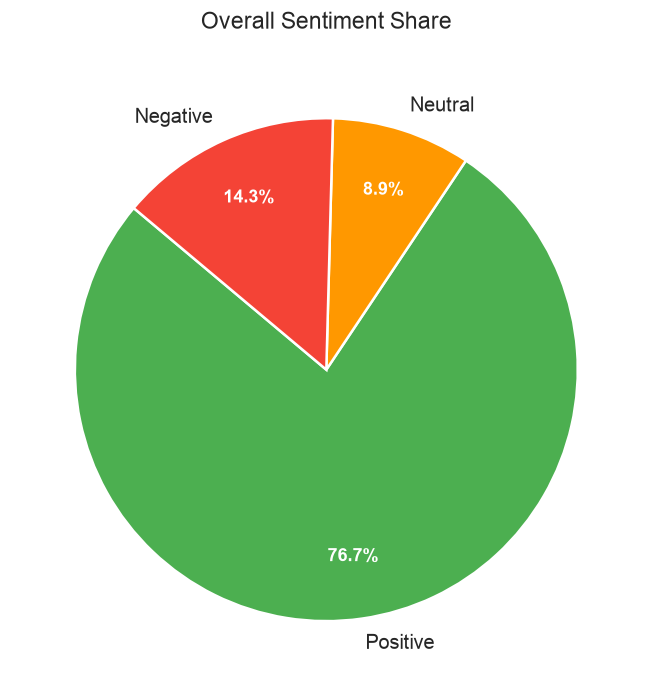

In [15]:
overall = combined["sentiment_label"].value_counts()[SENTIMENT_ORDER]

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    overall.values,
    labels=[s.capitalize() for s in overall.index],
    colors=[SENTIMENT_PALETTE[s] for s in overall.index],
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.75,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_color("white")
    t.set_fontweight("bold")
ax.set_title("Overall Sentiment Share", fontsize=14, pad=16)
plt.tight_layout()
plt.show()

### 2e. Per-Category Sentiment Breakdown — Small Multiples

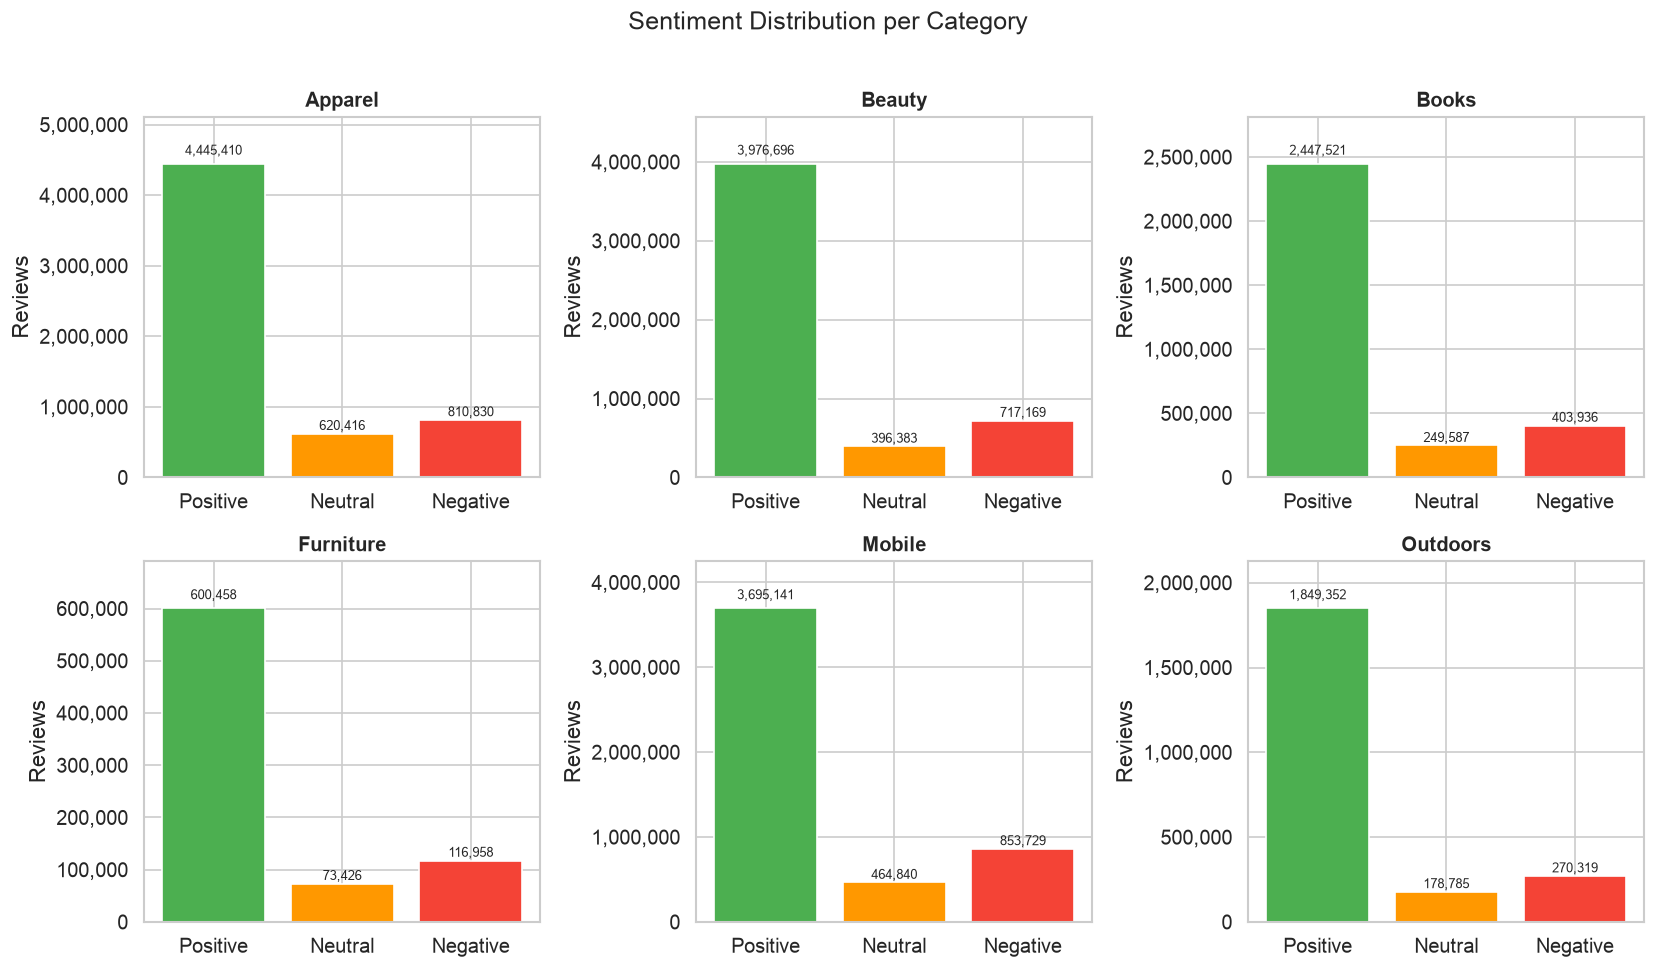

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, (cat, df) in zip(axes, dfs.items()):
    counts = df["sentiment_label"].value_counts()[SENTIMENT_ORDER]
    bars = ax.bar(
        [s.capitalize() for s in SENTIMENT_ORDER],
        counts.values,
        color=[SENTIMENT_PALETTE[s] for s in SENTIMENT_ORDER],
        edgecolor="white",
    )
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.02,
            f"{int(bar.get_height()):,}",
            ha="center", va="bottom", fontsize=8
        )
    ax.set_title(cat, fontsize=12, fontweight="bold")
    ax.set_ylabel("Reviews")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.set_ylim(0, counts.max() * 1.15)

fig.suptitle("Sentiment Distribution per Category", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

---
## 3. Review Volume Over Time

### 3a. Annual Review Volume per Category

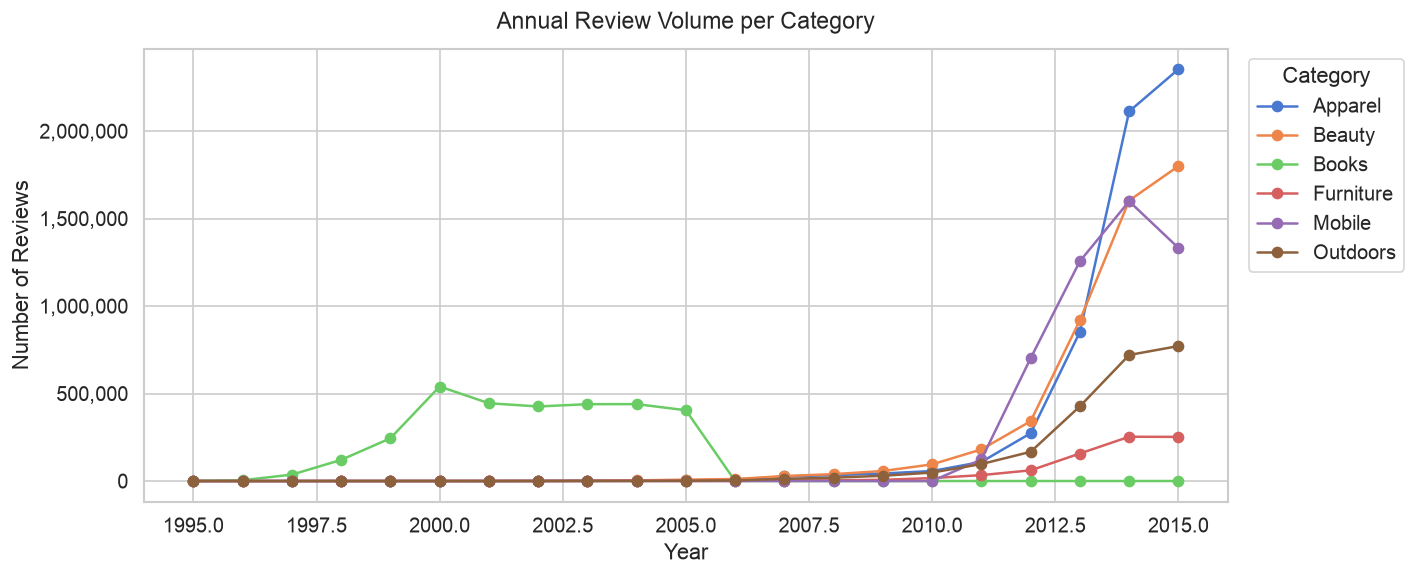


Yearly counts table:


,Apparel,Beauty,Books,Furniture,Mobile,Outdoors
review_year,,,,,,
1995,0,0,198,0,0,0
1996,0,0,4669,0,0,0
1997,0,0,36601,0,0,0
1998,0,0,120797,0,0,0
1999,0,0,244417,0,0,2
2000,6,33,540158,11,0,19
2001,5,257,444640,38,0,74
2002,907,567,426158,69,0,100
2003,2140,1252,439296,640,0,259


In [17]:
yearly = pd.DataFrame({
    cat: df.groupby("review_year").size()
    for cat, df in dfs.items()
}).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(12, 5))
for cat in CATEGORIES:
    ax.plot(yearly.index, yearly[cat], marker="o", label=cat, color=CAT_COLOR[cat])

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.set_title("Annual Review Volume per Category", fontsize=14, pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Reviews")
ax.legend(title="Category", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("\nYearly counts table:")
yearly

### 3b. Year × Month Heatmap — Review Volume Intensity (All Categories)

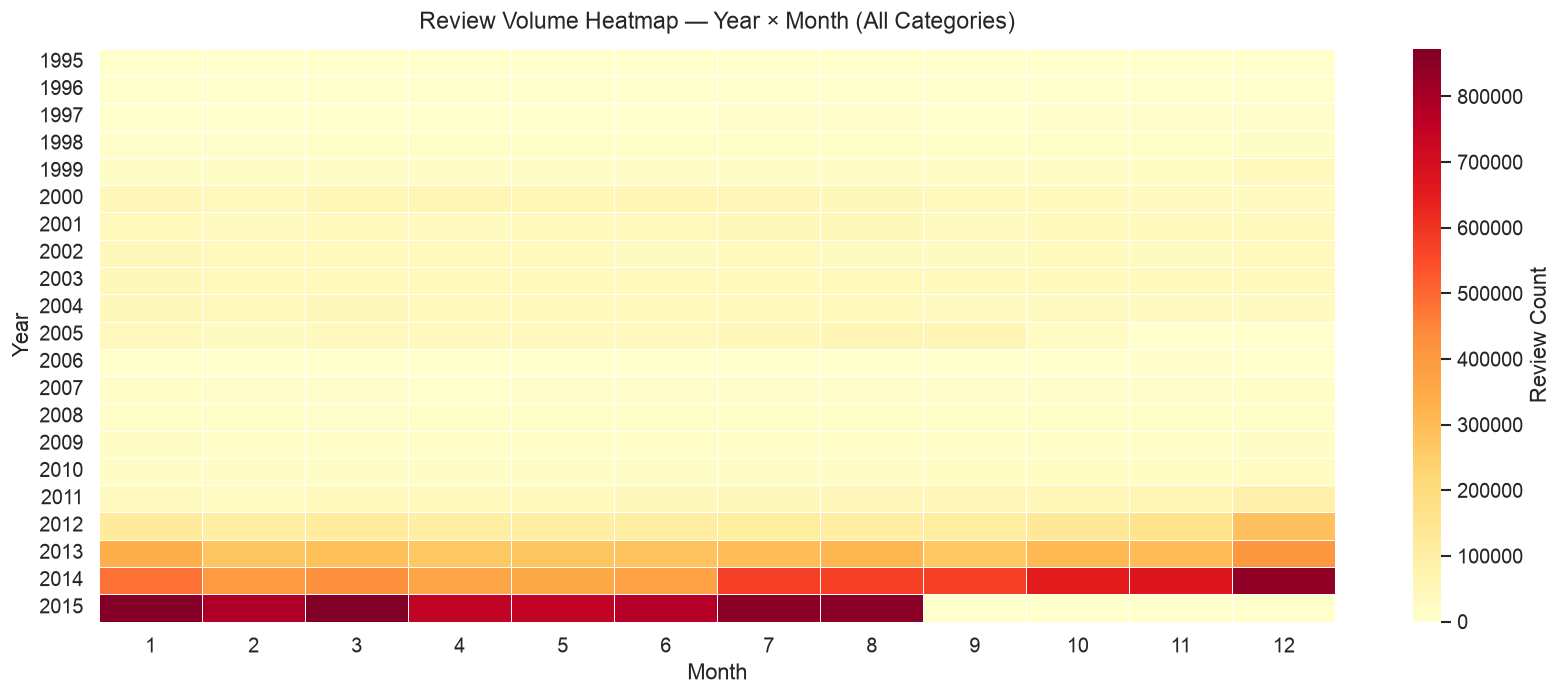

In [18]:
month_year = (
    combined.groupby(["review_year", "review_month"])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    month_year,
    ax=ax,
    cmap="YlOrRd",
    fmt=",d",
    linewidths=0.3,
    cbar_kws={"label": "Review Count"},
)
ax.set_title("Review Volume Heatmap — Year × Month (All Categories)", fontsize=14, pad=12)
ax.set_xlabel("Month")
ax.set_ylabel("Year")
plt.tight_layout()
plt.show()

### 3c. Day-of-Week Distribution

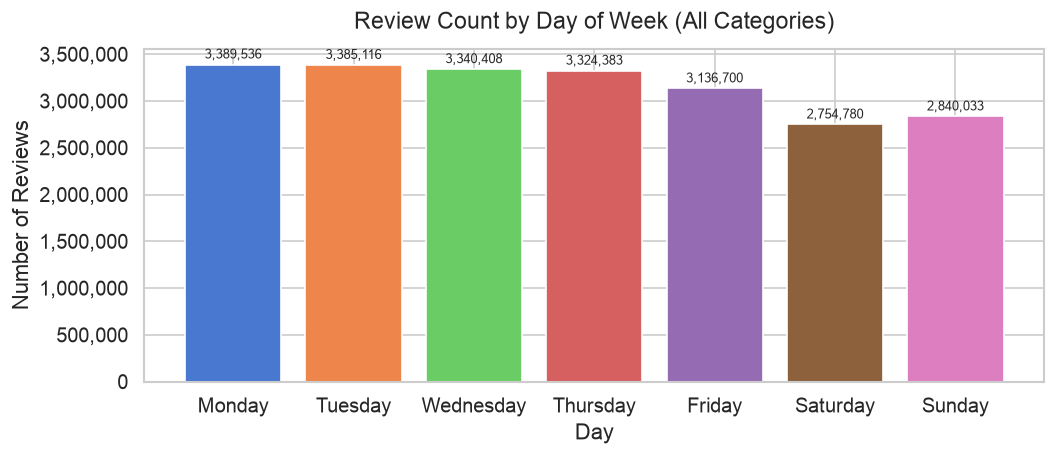

In [19]:
DOW_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

dow_counts = combined["review_day_of_week"].value_counts().reindex(DOW_ORDER)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(DOW_ORDER, dow_counts.values, color=sns.color_palette("muted", 7), edgecolor="white")
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f"{int(bar.get_height()):,}",
        ha="center", va="bottom", fontsize=8
    )
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.set_title("Review Count by Day of Week (All Categories)", fontsize=14, pad=12)
ax.set_xlabel("Day")
ax.set_ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

---
## 4. Helpfulness & Voting Patterns

### 4a. Vote Coverage — % of Reviews with at Least 1 Vote

In [20]:
vote_coverage = {
    cat: {
        "total_reviews":     len(df),
        "reviews_with_votes": int((df["total_votes"] > 0).sum()),
        "pct_with_votes":    round((df["total_votes"] > 0).mean() * 100, 2),
        "mean_total_votes":  round(df["total_votes"].astype(float).mean(), 3),
        "median_voted_only": round(
            df.loc[df["total_votes"] > 0, "total_votes"].astype(float).median(), 1
        ),
    }
    for cat, df in dfs.items()
}
coverage_df = pd.DataFrame(vote_coverage).T
coverage_df

,total_reviews,reviews_with_votes,pct_with_votes,mean_total_votes,median_voted_only
Apparel,5876656.0,1753788.0,29.84,1.164,1.0
Beauty,5090248.0,2210415.0,43.42,2.165,2.0
Books,3101044.0,2785252.0,89.82,12.397,7.0
Furniture,790842.0,362765.0,45.87,2.782,2.0
Mobile,5013710.0,1679987.0,33.51,3.441,2.0
Outdoors,2298456.0,966104.0,42.03,2.295,2.0


### 4b. Helpfulness Ratio Distribution (Voted Reviews Only)

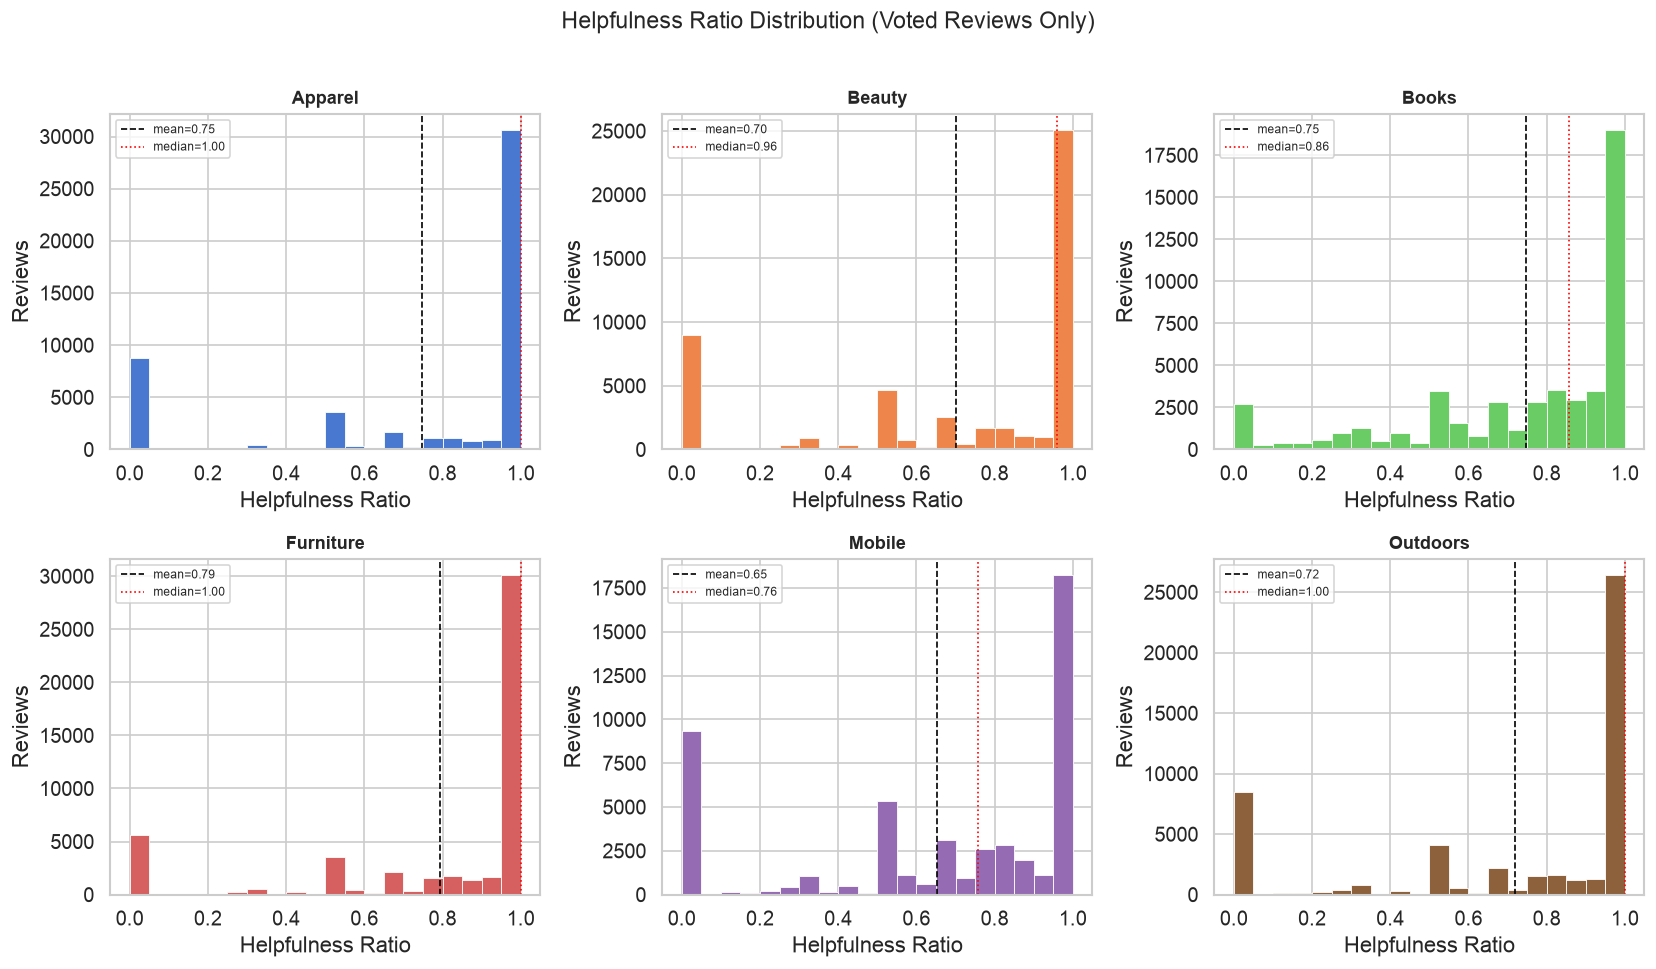

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=False)
axes = axes.flatten()

for ax, (cat, df) in zip(axes, dfs.items()):
    voted = df.loc[df["total_votes"] > 0, "helpfulness_ratio"].sample(
        min(50_000, (df["total_votes"] > 0).sum()), random_state=42
    )
    ax.hist(voted, bins=20, color=CAT_COLOR[cat], edgecolor="white", linewidth=0.5)
    ax.axvline(voted.mean(), color="black", linestyle="--", linewidth=1, label=f"mean={voted.mean():.2f}")
    ax.axvline(voted.median(), color="red", linestyle=":", linewidth=1, label=f"median={voted.median():.2f}")
    ax.set_title(cat, fontsize=11, fontweight="bold")
    ax.set_xlabel("Helpfulness Ratio")
    ax.set_ylabel("Reviews")
    ax.legend(fontsize=7)

fig.suptitle("Helpfulness Ratio Distribution (Voted Reviews Only)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 4c. Helpfulness Ratio by Sentiment (Voted Reviews Only)

/var/folders/sb/4cll4vyd5715mdws72rhnx1h0000gn/T/ipykernel_34410/1643119161.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


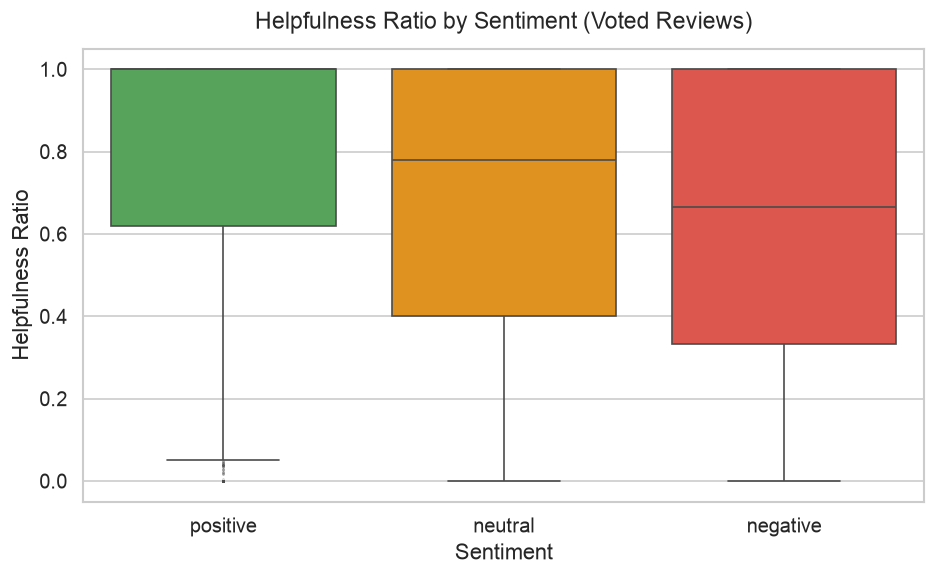

,mean,median,std
sentiment_label,,,
positive,0.7602,1.0000,0.3432
neutral,0.6533,0.7805,0.3796
negative,0.5996,0.6667,0.3688


In [21]:
voted_combined = combined[combined["total_votes"] > 0].sample(200_000, random_state=42)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=voted_combined,
    x="sentiment_label",
    y="helpfulness_ratio",
    order=SENTIMENT_ORDER,
    palette=SENTIMENT_PALETTE,
    ax=ax,
    flierprops={"marker": ".", "markersize": 1, "alpha": 0.3},
)
ax.set_title("Helpfulness Ratio by Sentiment (Voted Reviews)", fontsize=14, pad=12)
ax.set_xlabel("Sentiment")
ax.set_ylabel("Helpfulness Ratio")
plt.tight_layout()
plt.show()

# Summary stats
voted_combined.groupby("sentiment_label")["helpfulness_ratio"].agg(
    ["mean", "median", "std"]
).round(4).loc[SENTIMENT_ORDER]

### 4e. Scatter — Total Votes vs Helpfulness Ratio

In [ ]:
scatter_data = (
    combined[combined["total_votes"] > 0]
    .sample(30_000, random_state=42)
)
scatter_data = scatter_data[scatter_data["total_votes"] <= cap]

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(
    scatter_data["total_votes"],
    scatter_data["helpfulness_ratio"],
    c=scatter_data["source_category"].map({c: i for i, c in enumerate(CATEGORIES)}),
    cmap="tab10",
    alpha=0.2,
    s=5,
)
handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=plt.cm.tab10(i / len(CATEGORIES)),
               markersize=7, label=cat)
    for i, cat in enumerate(CATEGORIES)
]
ax.legend(handles=handles, title="Category", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_title("Total Votes vs Helpfulness Ratio (sample 30k voted reviews)", fontsize=13, pad=12)
ax.set_xlabel("Total Votes")
ax.set_ylabel("Helpfulness Ratio")
plt.tight_layout()
plt.show()

---
## 5. Product-Level Analysis

### 5a. Reviews per Product — Summary Statistics

In [25]:
prod_stats = []
for cat, df in dfs.items():
    counts = df.groupby("product_id").size()
    prod_stats.append({
        "category":        cat,
        "unique_products": len(counts),
        "mean_reviews":    round(counts.mean(), 1),
        "median_reviews":  round(counts.median(), 1),
        "max_reviews":     int(counts.max()),
        "p90_reviews":     int(counts.quantile(0.90)),
        "p99_reviews":     int(counts.quantile(0.99)),
    })

pd.DataFrame(prod_stats).set_index("category")

,unique_products,mean_reviews,median_reviews,max_reviews,p90_reviews,p99_reviews
category,,,,,,
Apparel,2294214,2.6,1.0,1834,4,23
Beauty,587069,8.7,2.0,15503,14,118
Books,778946,4.0,1.0,4618,7,38
Furniture,140881,5.6,1.0,2799,9,78
Mobile,126814,39.5,2.0,49837,31,618
Outdoors,391268,5.9,1.0,6020,9,78


### 5b. Top 10 Most-Reviewed Products per Category

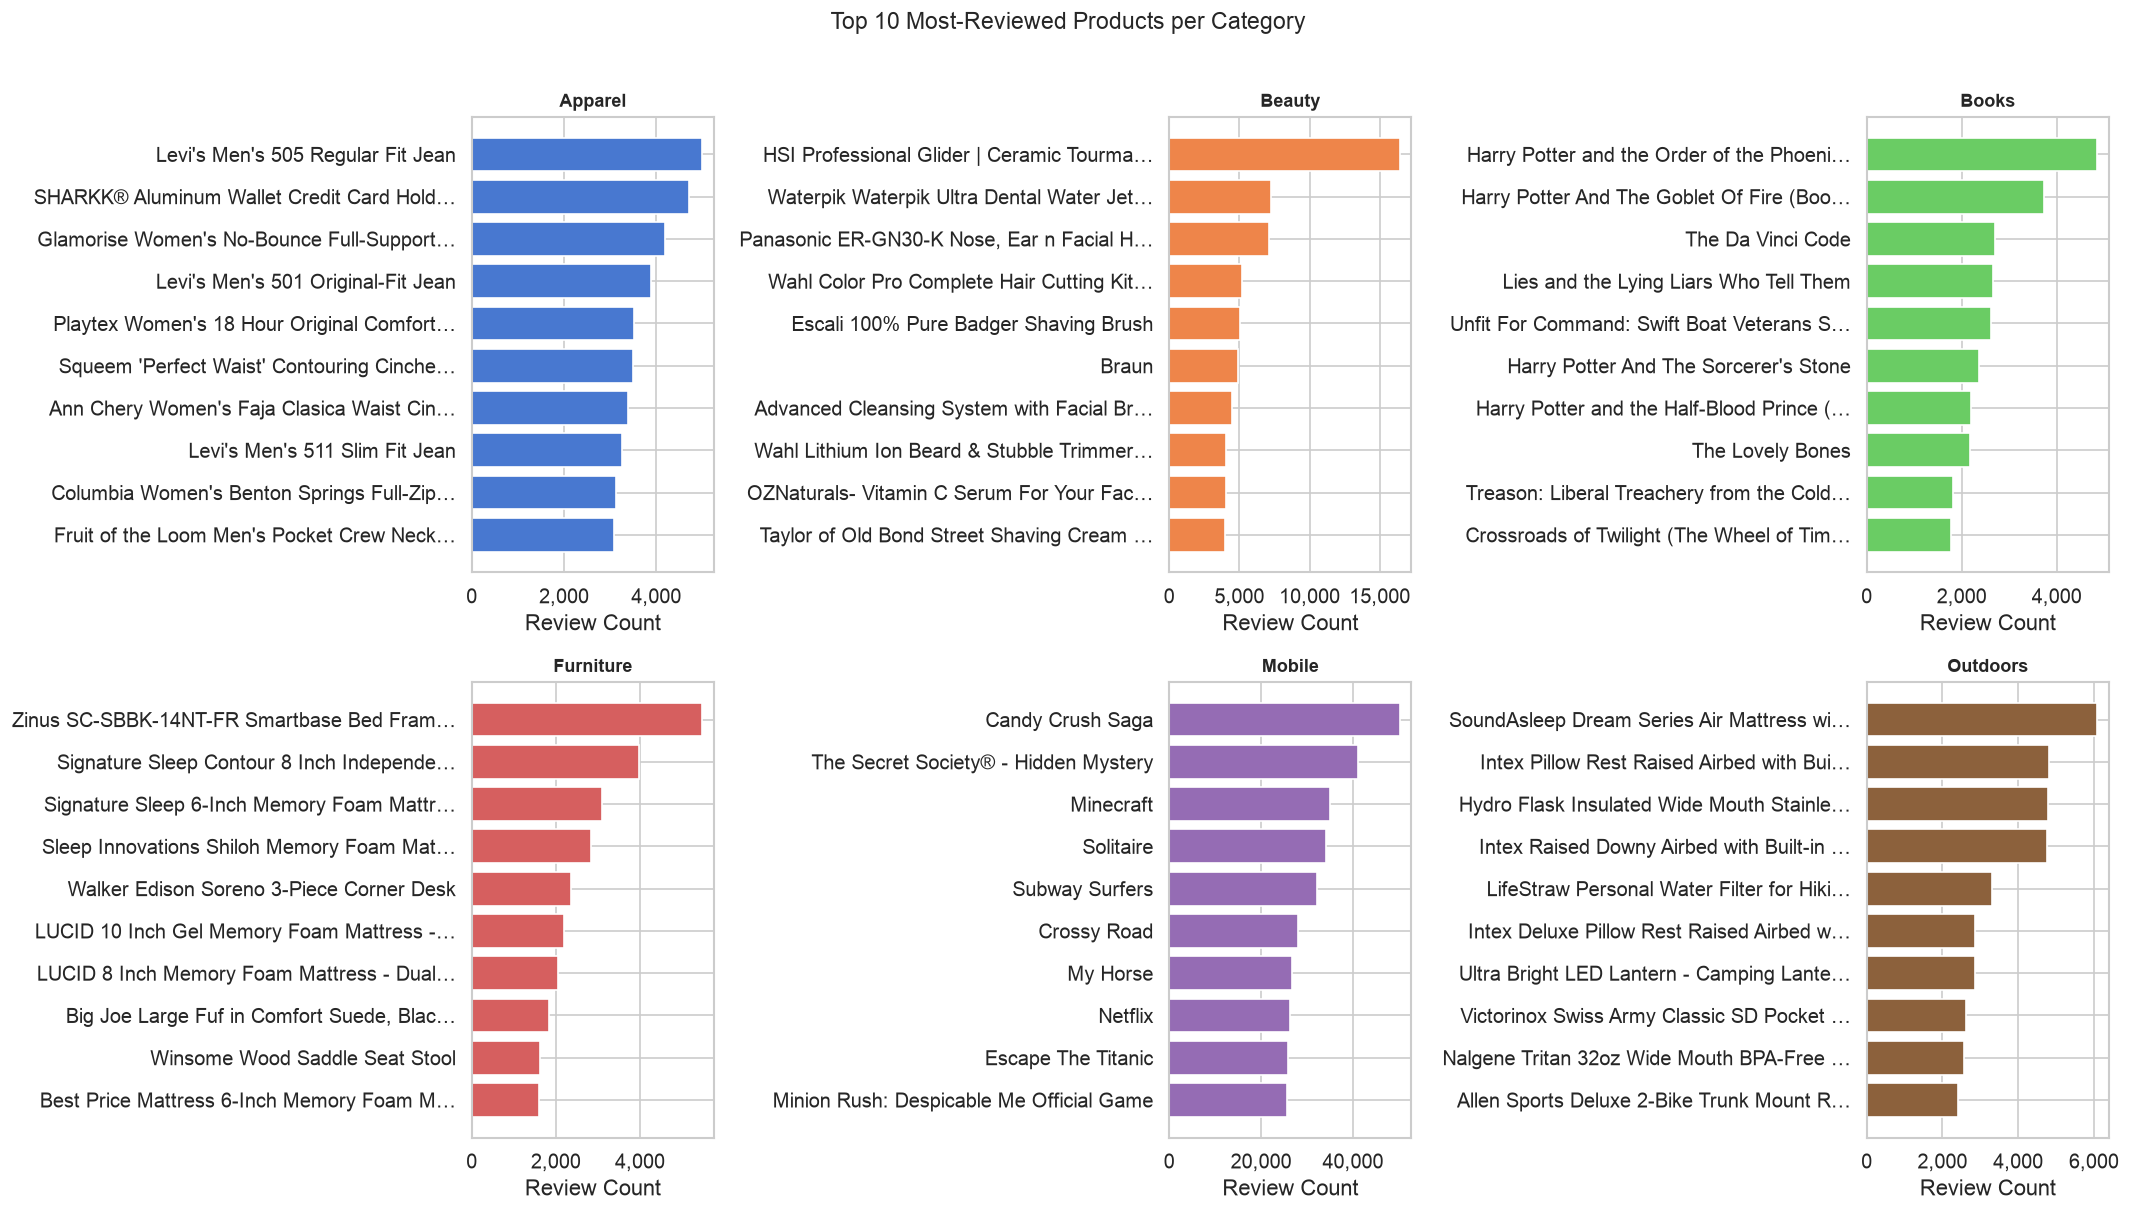

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (cat, df) in zip(axes, dfs.items()):
    top = df.groupby("product_title").size().nlargest(10).sort_values()
    labels = [t[:40] + "…" if len(t) > 40 else t for t in top.index]
    ax.barh(labels, top.values, color=CAT_COLOR[cat], edgecolor="white")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.set_title(cat, fontsize=11, fontweight="bold")
    ax.set_xlabel("Review Count")

fig.suptitle("Top 10 Most-Reviewed Products per Category", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 5c. Top 10 Most Polarizing Products per Category

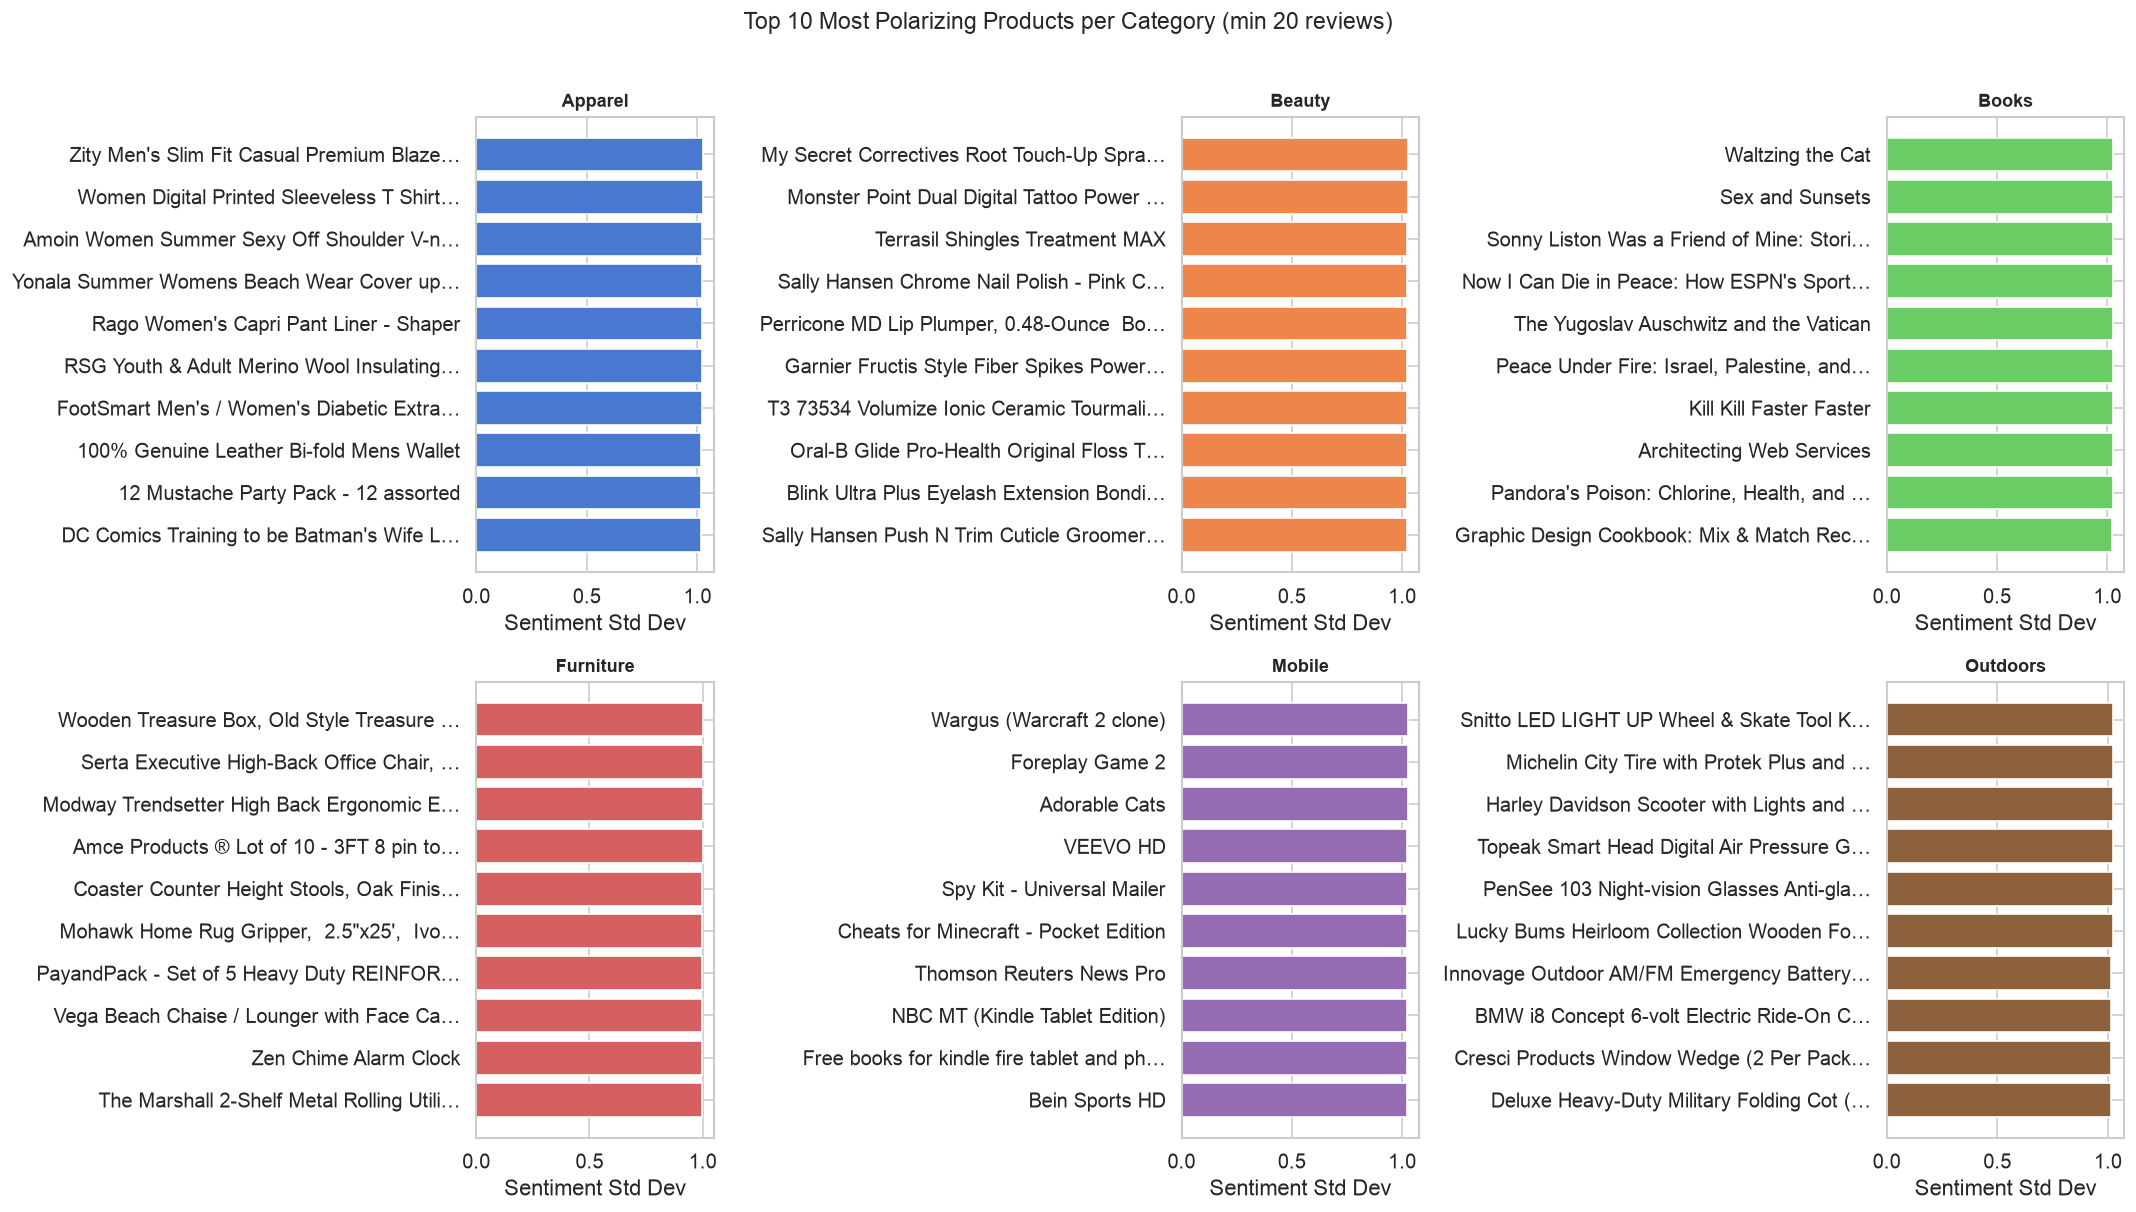

In [27]:
SENT_NUM = {"positive": 1, "neutral": 0, "negative": -1}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (cat, df) in zip(axes, dfs.items()):
    tmp = df.copy()
    tmp["sent_num"] = tmp["sentiment_label"].map(SENT_NUM)
    polar = (
        tmp.groupby("product_title")["sent_num"]
        .agg(["std", "count"])
        .query("count >= 20")["std"]
        .nlargest(10).sort_values()
    )
    labels = [t[:40] + "…" if len(t) > 40 else t for t in polar.index]
    ax.barh(labels, polar.values, color=CAT_COLOR[cat], edgecolor="white")
    ax.set_title(cat, fontsize=11, fontweight="bold")
    ax.set_xlabel("Sentiment Std Dev")

fig.suptitle("Top 10 Most Polarizing Products per Category (min 20 reviews)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Cross-Category Comparison Summary

### 6a. Summary Metrics Table

In [28]:
summary = {}
for cat, df in dfs.items():
    voted = df[df["total_votes"] > 0]
    word_counts = df["review"].sample(50_000, random_state=42).str.split().str.len()
    summary[cat] = {
        "review_count":     len(df),
        "pct_positive":     round((df["sentiment_label"] == "positive").mean() * 100, 1),
        "pct_negative":     round((df["sentiment_label"] == "negative").mean() * 100, 1),
        "avg_helpfulness":  round(voted["helpfulness_ratio"].mean(), 3),
        "pct_with_votes":   round((df["total_votes"] > 0).mean() * 100, 1),
        "pct_verified":     round((df["verified_purchase"] == "Y").mean() * 100, 1),
        "avg_review_words": round(word_counts.mean(), 1),
        "unique_products":  df["product_id"].nunique(),
    }

summary_df = pd.DataFrame(summary).T
summary_df

,review_count,pct_positive,pct_negative,avg_helpfulness,pct_with_votes,pct_verified,avg_review_words,unique_products
Apparel,5876656.0,75.6,13.8,0.745,29.8,89.9,37.8,2294214.0
Beauty,5090248.0,78.1,14.1,0.704,43.4,82.7,52.2,587069.0
Books,3101044.0,78.9,13.0,0.749,89.8,7.4,157.7,778946.0
Furniture,790842.0,75.9,14.8,0.793,45.9,90.7,60.5,140881.0
Mobile,5013710.0,73.7,17.0,0.651,33.5,95.1,32.4,126814.0
Outdoors,2298456.0,80.5,11.8,0.717,42.0,88.0,60.7,391268.0


### 6b. Radar Chart — Category Profiles

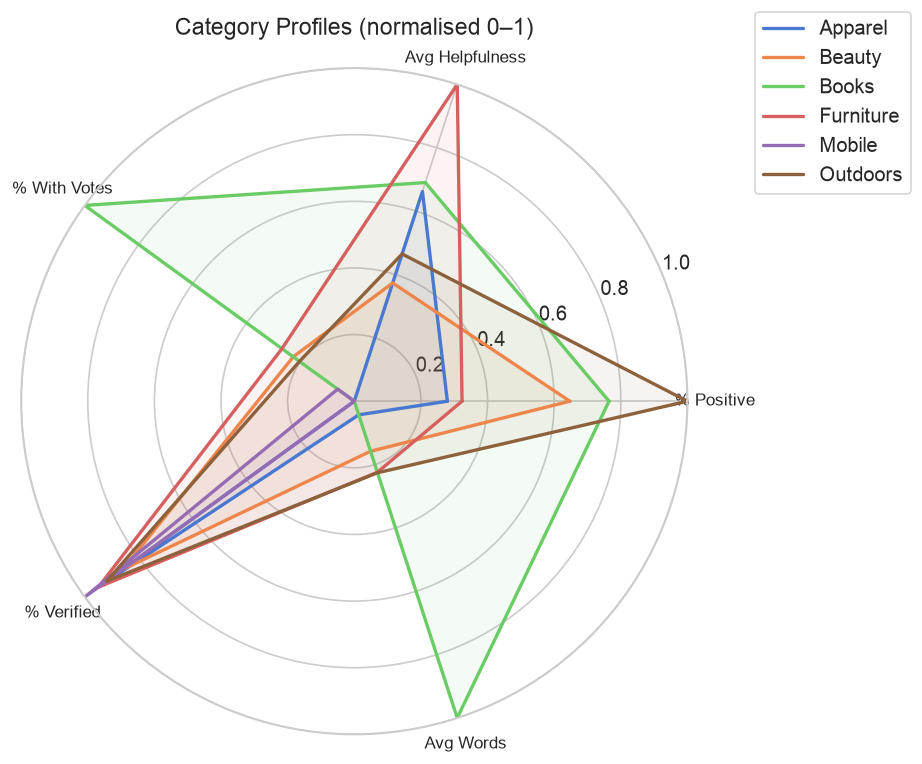

In [29]:
radar_cols   = ["pct_positive", "avg_helpfulness", "pct_with_votes", "pct_verified", "avg_review_words"]
radar_labels = ["% Positive", "Avg Helpfulness", "% With Votes", "% Verified", "Avg Words"]

radar_data = summary_df[radar_cols].astype(float)
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

N      = len(radar_cols)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"polar": True})
for cat in CATEGORIES:
    values = radar_norm.loc[cat].tolist() + [radar_norm.loc[cat].tolist()[0]]
    ax.plot(angles, values, label=cat, color=CAT_COLOR[cat], linewidth=2)
    ax.fill(angles, values, color=CAT_COLOR[cat], alpha=0.07)

ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title("Category Profiles (normalised 0–1)", fontsize=14, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()

### 6c. Helpfulness Ratio Box Plots Across All Categories

TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'. Did you mean 'label'?

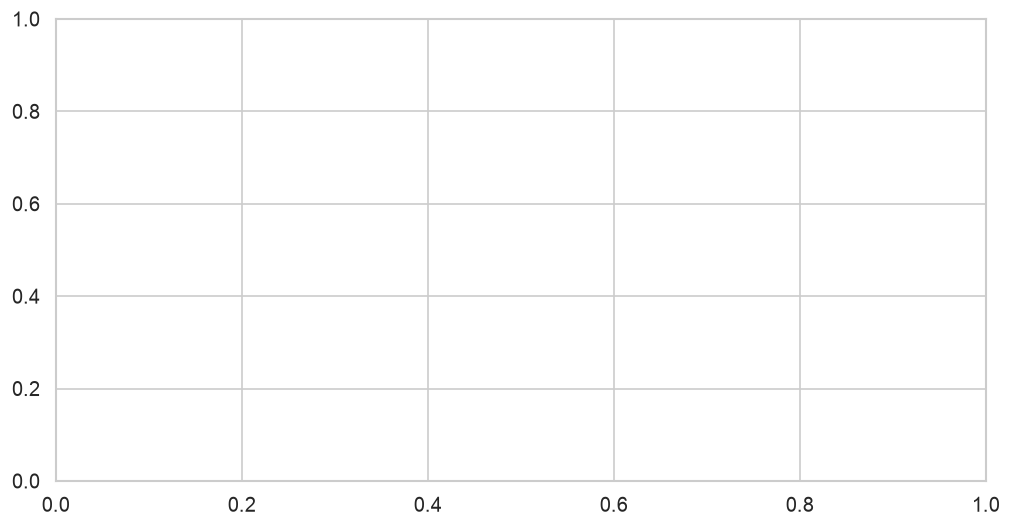

In [30]:
box_data = [
    dfs[cat].loc[dfs[cat]["total_votes"] > 0, "helpfulness_ratio"]
    .sample(min(30_000, (dfs[cat]["total_votes"] > 0).sum()), random_state=42).values
    for cat in CATEGORIES
]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(
    box_data, labels=CATEGORIES, patch_artist=True,
    flierprops={"marker": ".", "markersize": 1, "alpha": 0.2},
    medianprops={"color": "black", "linewidth": 2},
)
for patch, cat in zip(bp["boxes"], CATEGORIES):
    patch.set_facecolor(CAT_COLOR[cat])
    patch.set_alpha(0.8)

ax.set_title("Helpfulness Ratio by Category (Voted Reviews Only)", fontsize=13, pad=12)
ax.set_xlabel("Category")
ax.set_ylabel("Helpfulness Ratio")
plt.tight_layout()
plt.show()

---
## 7. Correlation Analysis

### 7a. Pearson Correlation Matrix — All Categories Combined

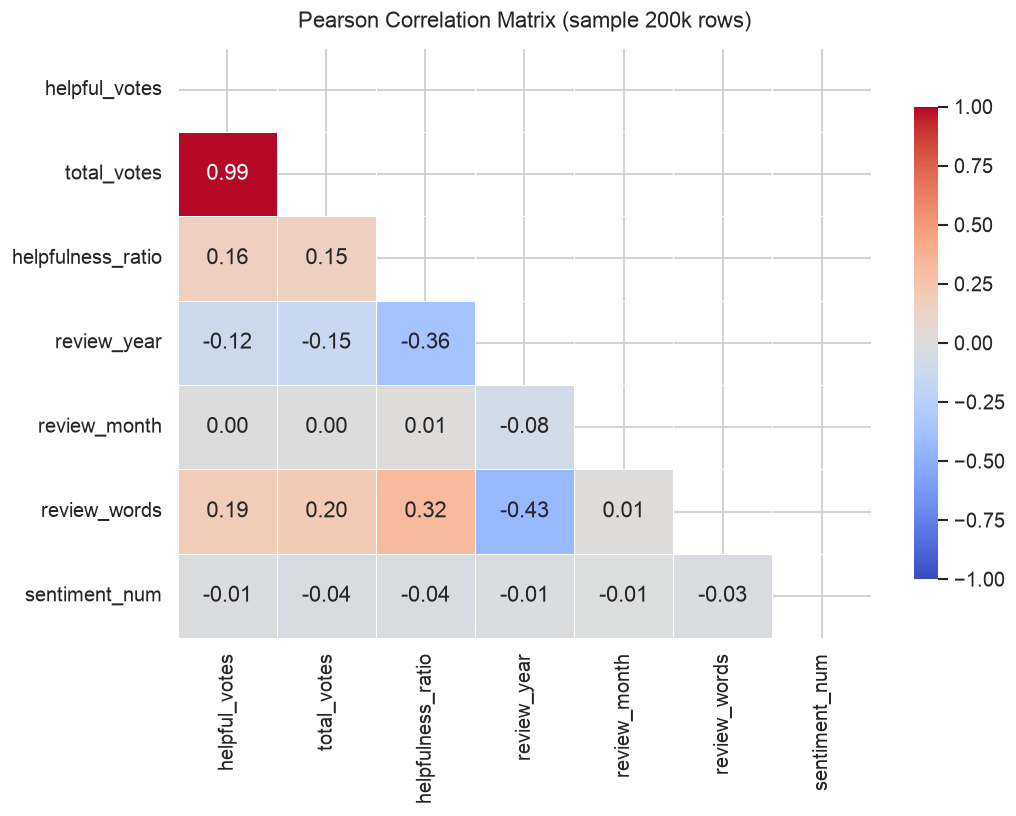


Full correlation table:


,helpful_votes,total_votes,helpfulness_ratio,review_year,review_month,review_words,sentiment_num
helpful_votes,1.000,0.986,0.160,-0.124,0.004,0.190,-0.015
total_votes,0.986,1.000,0.155,-0.145,0.005,0.200,-0.038
helpfulness_ratio,0.160,0.155,1.000,-0.362,0.010,0.319,-0.044
review_year,-0.124,-0.145,-0.362,1.000,-0.082,-0.433,-0.013
review_month,0.004,0.005,0.010,-0.082,1.000,0.010,-0.006
review_words,0.190,0.200,0.319,-0.433,0.010,1.000,-0.027
sentiment_num,-0.015,-0.038,-0.044,-0.013,-0.006,-0.027,1.000


In [31]:
SENT_NUM = {"positive": 1, "neutral": 0, "negative": -1}

corr_sample = combined.sample(200_000, random_state=42).copy()
corr_sample["review_words"]  = corr_sample["review"].str.split().str.len()
corr_sample["sentiment_num"] = corr_sample["sentiment_label"].map(SENT_NUM)

corr_cols = ["helpful_votes", "total_votes", "helpfulness_ratio",
             "review_year", "review_month", "review_words", "sentiment_num"]

corr_matrix = corr_sample[corr_cols].astype(float).corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8},
)
ax.set_title("Pearson Correlation Matrix (sample 200k rows)", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

print("\nFull correlation table:")
corr_matrix.round(3)

### 7b. Correlation Heatmap per Category

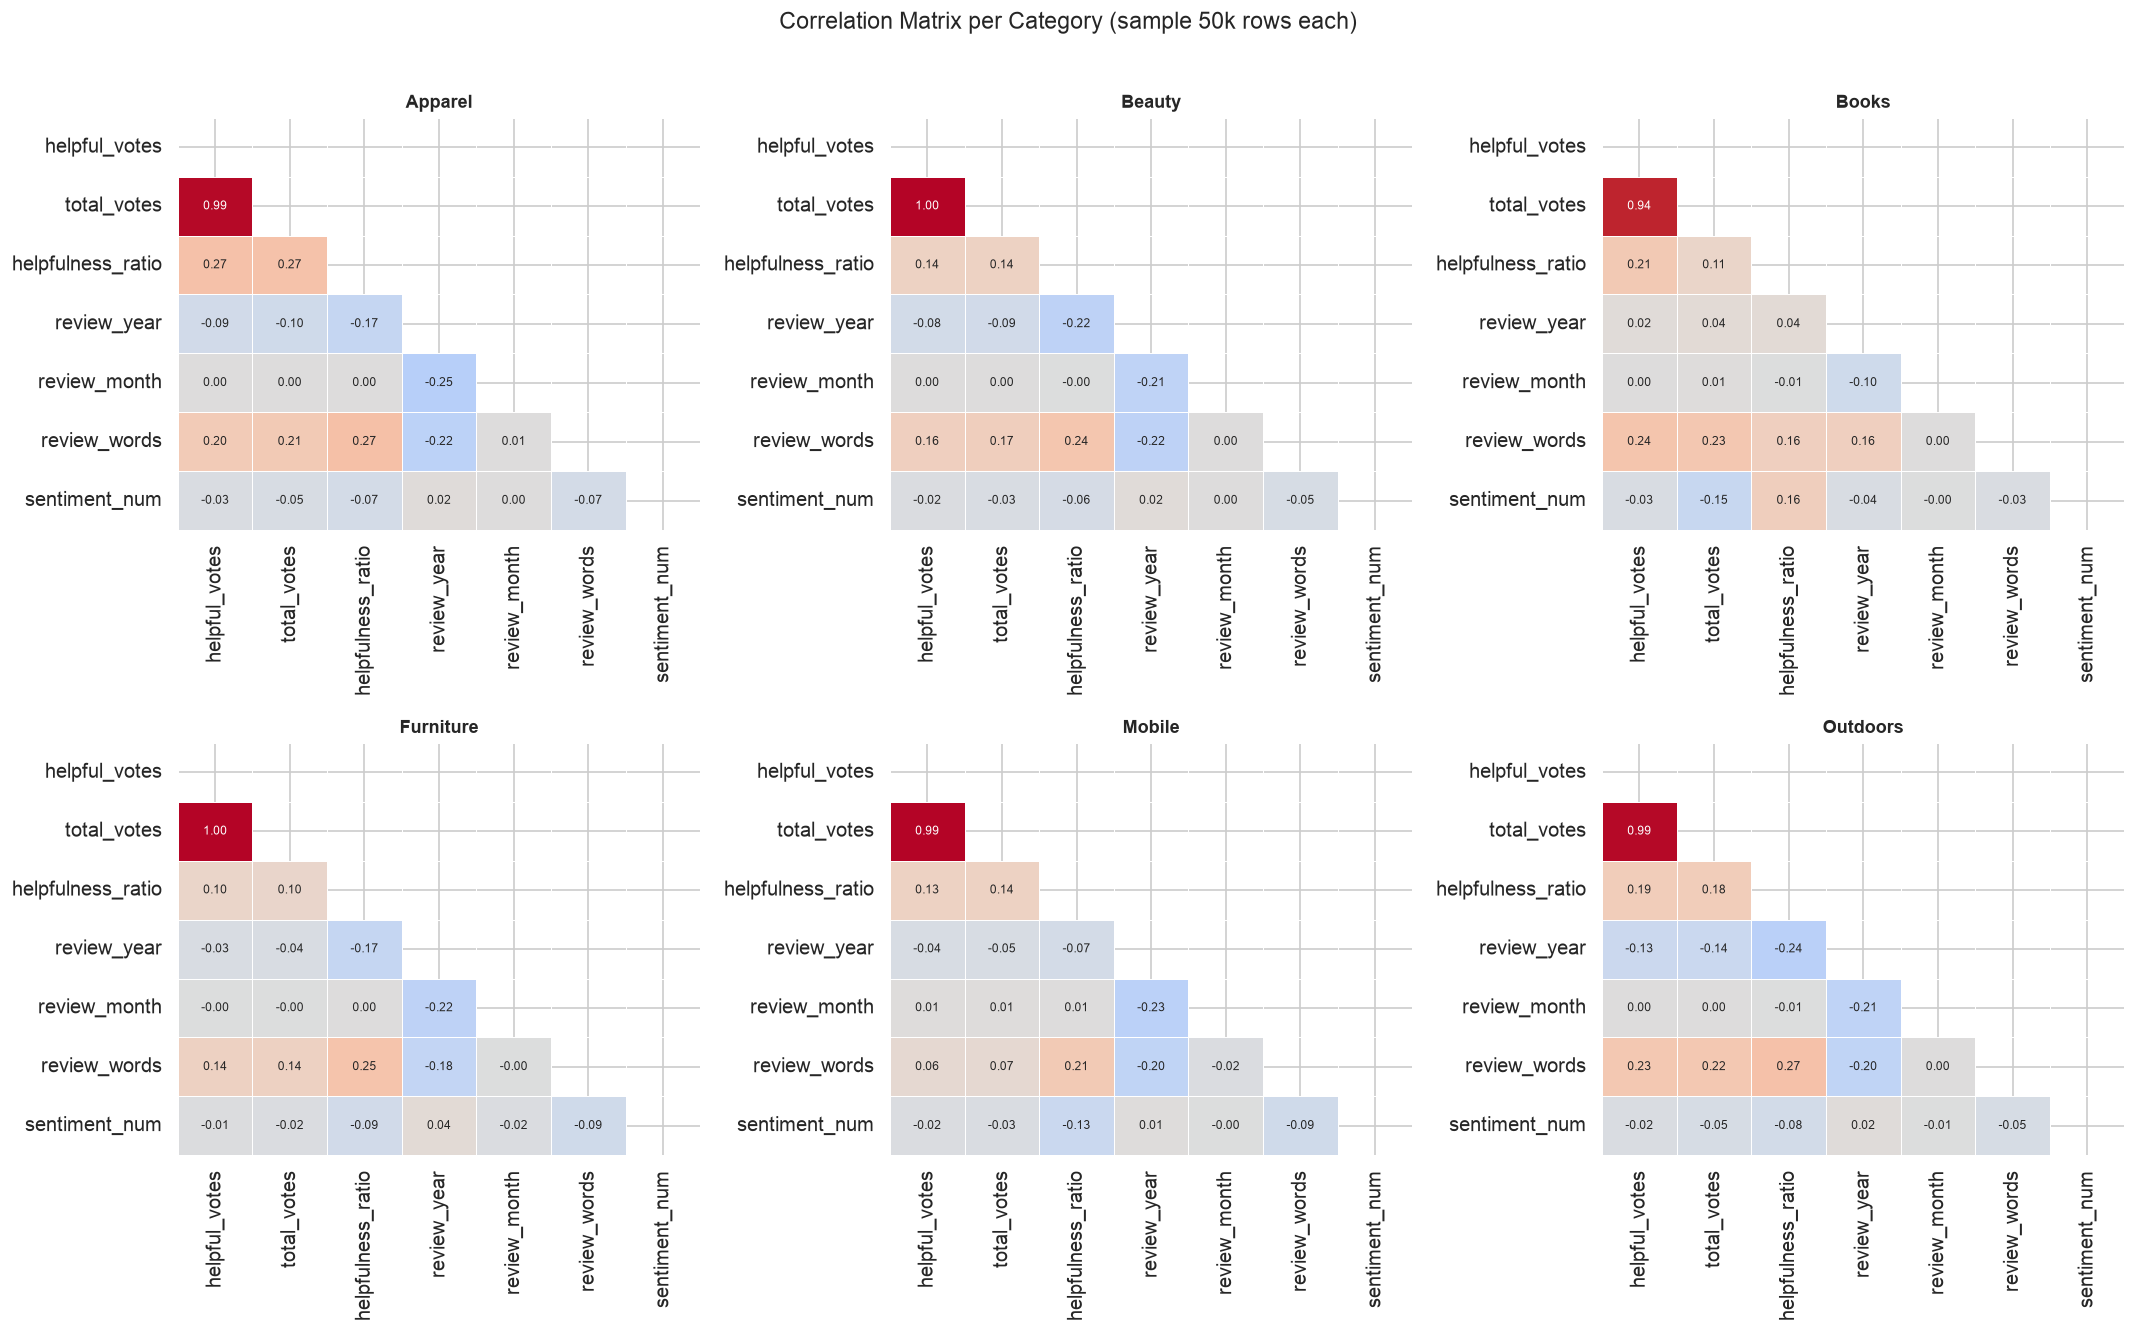

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for ax, (cat, df) in zip(axes, dfs.items()):
    s = df.sample(min(50_000, len(df)), random_state=42).copy()
    s["review_words"]  = s["review"].str.split().str.len()
    s["sentiment_num"] = s["sentiment_label"].map(SENT_NUM)
    cm   = s[corr_cols].astype(float).corr()
    mask = np.triu(np.ones_like(cm, dtype=bool))
    sns.heatmap(
        cm, mask=mask, annot=True, fmt=".2f",
        cmap="coolwarm", center=0, vmin=-1, vmax=1,
        linewidths=0.4, ax=ax, cbar=False, annot_kws={"size": 7},
    )
    ax.set_title(cat, fontsize=11, fontweight="bold")

fig.suptitle("Correlation Matrix per Category (sample 50k rows each)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()